# 14 — Final realistic-bumpy synthetic benchmark

This final stage evaluates the completed calibration pipeline on a controlled,
realistic multi-feature surface.

We test four methods on the same noisy European call-price surface:

1. raw finite-difference Dupire;
2. spline-smoothed price surface followed by Dupire;
3. SSVI total-variance smoothing followed by Dupire;
4. the nonlinear operator/Schrödinger-regularised inverse method.

The known truth is a smooth equity-style local-volatility surface with:

- short-dated term structure;
- persistent downside skew;
- smile curvature;
- a broad downside event elevation around three months;
- a smaller medium-term volatility depression;
- a short-dated downside-wing ridge.

The surface is deliberately more realistic than a single isolated Gaussian
bump, while remaining fully known so reconstruction accuracy can be measured.

In [1]:
%load_ext autoreload
%autoreload 2

import json
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd().resolve()
if not (project_root / "src").exists():
    if (project_root.parent / "src").exists():
        project_root = project_root.parent
    else:
        raise FileNotFoundError(
            "Could not find the project root. Start Jupyter from the "
            "project root or notebooks folder."
        )

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Project root:", project_root)

Project root: /mnt/data/dupire_audit/dupire_local_vol_project


## 1. Run the final benchmark

The script builds the synthetic market, selects the operator regularisation
strength by GCV, runs the nonlinear calibration, fits SSVI, evaluates all four
methods and repeats the noise experiment ten times.

Set `RUN_BENCHMARK = False` after the outputs have been generated once.

In [2]:
RUN_BENCHMARK = False
MODE = "full"  # change to "quick" only for an implementation check

if RUN_BENCHMARK:
    subprocess.run(
        [
            sys.executable,
            str(
                project_root
                / "scripts"
                / "14_run_realistic_bumpy_benchmark.py"
            ),
            "--project-root",
            str(project_root),
            "--mode",
            MODE,
            "--overwrite",
        ],
        check=True,
    )

In [3]:
from src.evaluation.realistic_bumpy_benchmark import (
    realistic_bumpy_local_volatility,
    realistic_equity_base_surface,
)

output_directory = project_root / "outputs" / "stage_14_final"
required = [
    output_directory / "common_grid_comparison.csv",
    output_directory / "pointwise_results.csv",
    output_directory / "feature_recovery_metrics.csv",
    output_directory / "repeated_noise_summary.csv",
    output_directory / "benchmark_summary.json",
]
for path in required:
    if not path.exists():
        raise FileNotFoundError(f"Missing output: {path}")

comparison = pd.read_csv(output_directory / "common_grid_comparison.csv")
pointwise = pd.read_csv(output_directory / "pointwise_results.csv")
feature_metrics = pd.read_csv(output_directory / "feature_recovery_metrics.csv")
noise_results = pd.read_csv(output_directory / "repeated_noise_results.csv")
noise_summary = pd.read_csv(output_directory / "repeated_noise_summary.csv")
summary = json.loads(
    (output_directory / "benchmark_summary.json").read_text(encoding="utf-8")
)
summary

{'mode': 'full',
 'number_of_quotes': 136,
 'number_of_operator_unknowns': 66,
 'selected_lambda': 1000.0,
 'operator_stop_reason': 'relative_objective_tolerance',
 'operator_final_weighted_price_rmse': 0.9216706731282666,
 'single_noise_local_volatility_winner': 'operator_regularized',
 'repeated_noise_mean_rmse_winner': 'operator_regularized_linearized',
 'shared_valid_fraction': 0.8823529411764706,
 'ssvi_rho': -0.3493742147571887,
 'ssvi_eta': 0.5373032415120966,
 'ssvi_gamma': 0.38842310490812965,
 'unit_square_cell_area': 0.020000000000000004}

## 2. The realistic multi-feature truth

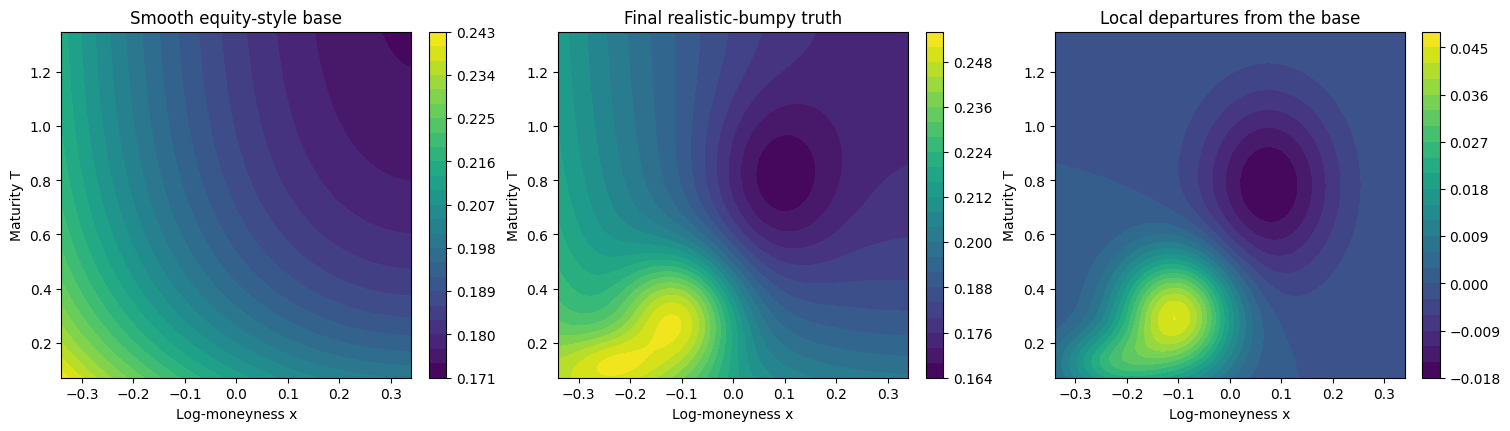

In [4]:
x_values = np.linspace(-0.34, 0.34, 121)
maturities = np.linspace(0.07, 1.35, 101)
x_mesh, T_mesh = np.meshgrid(x_values, maturities)

base_surface = realistic_equity_base_surface(x_mesh, T_mesh)
true_surface = realistic_bumpy_local_volatility(x_mesh, T_mesh)
feature_surface = true_surface - base_surface

figure, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
for axis, values, title in [
    (axes[0], base_surface, "Smooth equity-style base"),
    (axes[1], true_surface, "Final realistic-bumpy truth"),
    (axes[2], feature_surface, "Local departures from the base"),
]:
    contour = axis.contourf(x_values, maturities, values, levels=24)
    figure.colorbar(contour, ax=axis)
    axis.set_title(title)
    axis.set_xlabel("Log-moneyness x")
    axis.set_ylabel("Maturity T")
plt.show()

## 3. Common-grid reconstruction accuracy

Every method is scored on the same points at which all four local-volatility
estimates are valid. The valid fraction is reported separately so instability
in raw differentiation is not hidden.

In [5]:
comparison

,number_of_evaluation_points,rmse,mae,maximum_absolute_error,bias,method,method_valid_fraction
0,120,0.005707,0.004472,0.017363,0.000958,operator_regularized,1.000000
1,120,0.011951,0.007231,0.064044,0.003296,ssvi_dupire,1.000000
2,120,0.036831,0.015126,0.302948,0.006817,smoothed_dupire,0.926471
3,120,0.061627,0.027544,0.345973,0.006772,raw_dupire,0.897059


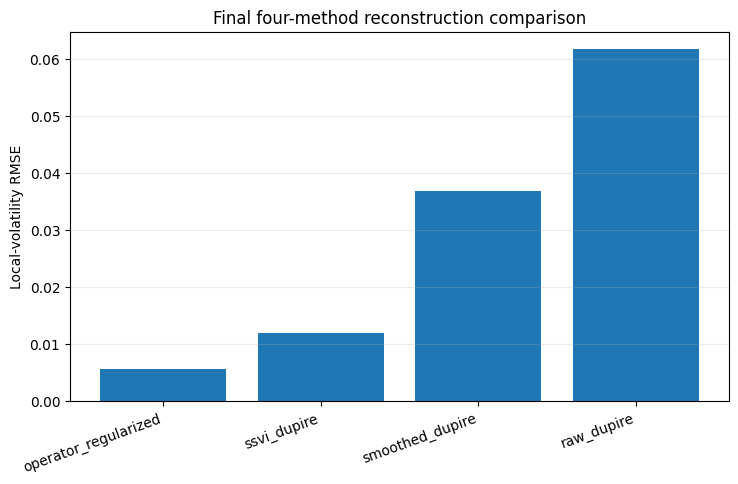

In [6]:
plt.figure(figsize=(8.5, 4.8))
ordered = comparison.sort_values("rmse")
plt.bar(ordered["method"], ordered["rmse"])
plt.ylabel("Local-volatility RMSE")
plt.title("Final four-method reconstruction comparison")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.show()

## 4. Surface reconstruction plots

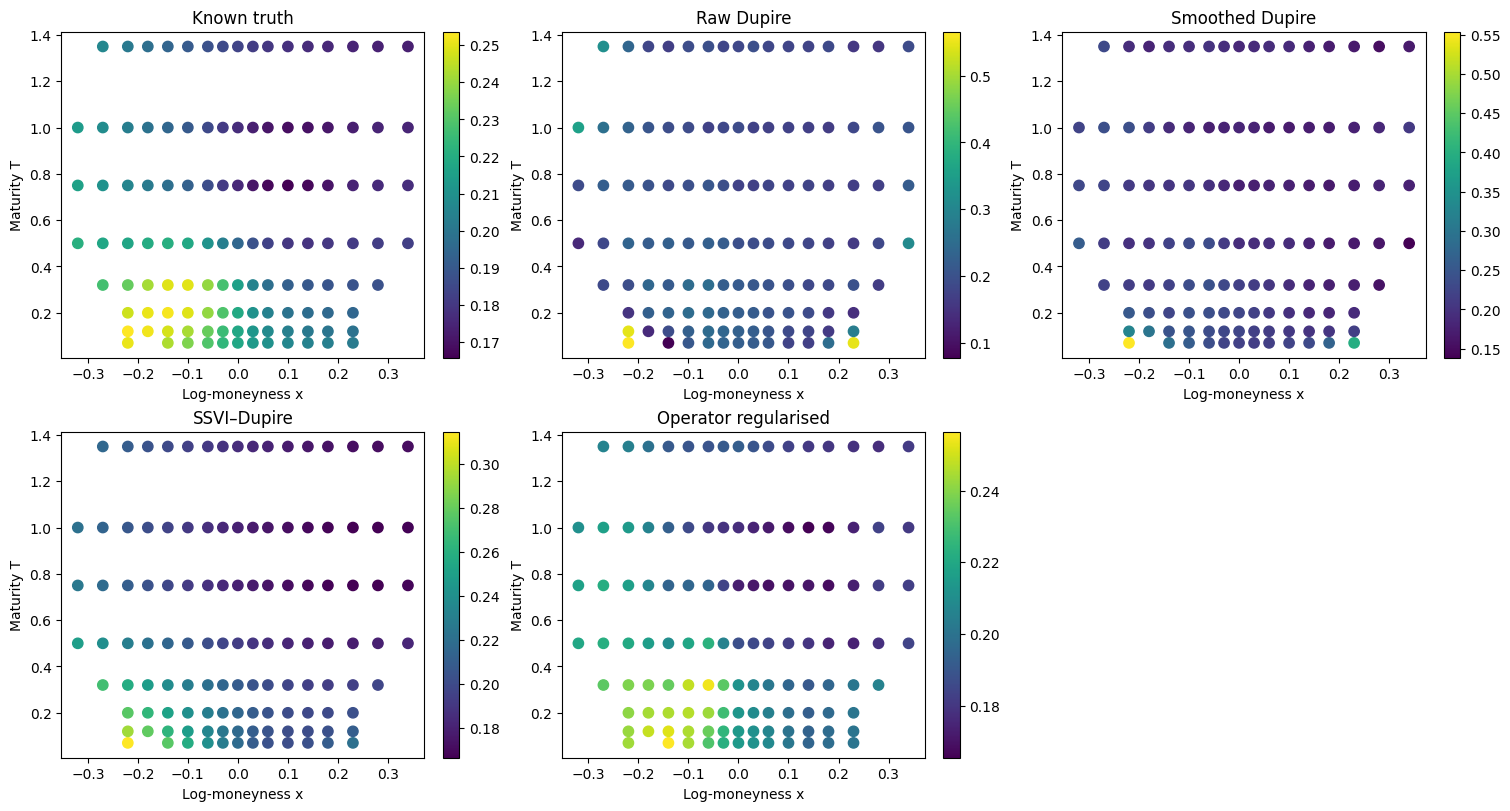

In [7]:
shared = pointwise[pointwise["shared_valid"]].copy()
plot_columns = [
    ("true_local_volatility", "Known truth"),
    ("raw_dupire", "Raw Dupire"),
    ("smoothed_dupire", "Smoothed Dupire"),
    ("ssvi_dupire", "SSVI–Dupire"),
    ("operator_regularized", "Operator regularised"),
]

figure, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
for axis, (column, title) in zip(axes.reshape(-1), plot_columns):
    scatter = axis.scatter(
        shared["log_moneyness"],
        shared["maturity"],
        c=shared[column],
        s=55,
    )
    figure.colorbar(scatter, ax=axis)
    axis.set_title(title)
    axis.set_xlabel("Log-moneyness x")
    axis.set_ylabel("Maturity T")

axes.reshape(-1)[-1].axis("off")
plt.show()

## 5. Recovery of the two main local features

The primary region contains the downside event elevation. The secondary region
contains the weaker medium-term depression. The feature correlation compares
the estimated departures from the smooth equity-style base with the true
departures.

In [8]:
feature_metrics

,method,overall_rmse,overall_mae,primary_event_rmse,secondary_dip_rmse,background_rmse,true_primary_excess,estimated_primary_excess,primary_amplitude_error,true_secondary_deviation,estimated_secondary_deviation,secondary_amplitude_error,feature_correlation
0,operator_regularized,0.005707,0.004472,0.006616,0.003466,0.005875,0.044233,0.052015,0.007783,-0.017536,-0.015206,0.002330,0.910156
1,ssvi_dupire,0.011951,0.007231,0.014208,0.003791,0.012684,0.044233,0.056591,0.012359,-0.017536,-0.012659,0.004877,0.768826
2,smoothed_dupire,0.036831,0.015126,0.017983,0.006402,0.047653,0.044233,0.077917,0.033684,-0.017536,-0.016176,0.001360,0.386858
3,raw_dupire,0.061627,0.027544,0.044429,0.008474,0.076787,0.044233,0.047995,0.003762,-0.017536,-0.016601,0.000935,0.170415


## 6. Robustness over ten independent noise realisations

The expensive nonlinear operator estimate is used for the main dataset. For
the repeated-noise check, the operator uses the same selected linearised inverse
map, while SSVI is refitted for every draw.

In [9]:
noise_summary

,method,mean_rmse,sd_rmse,minimum_rmse,maximum_rmse,mean_mae,mean_shared_valid_fraction
0,operator_regularized_linearized,0.007587,0.001011,0.006057,0.009710,0.005331,0.884559
1,ssvi_dupire,0.012812,0.001412,0.010910,0.014906,0.007720,0.884559
2,smoothed_dupire,0.035953,0.022035,0.016937,0.080475,0.014781,0.884559
3,raw_dupire,0.046336,0.014640,0.027604,0.072431,0.021916,0.884559


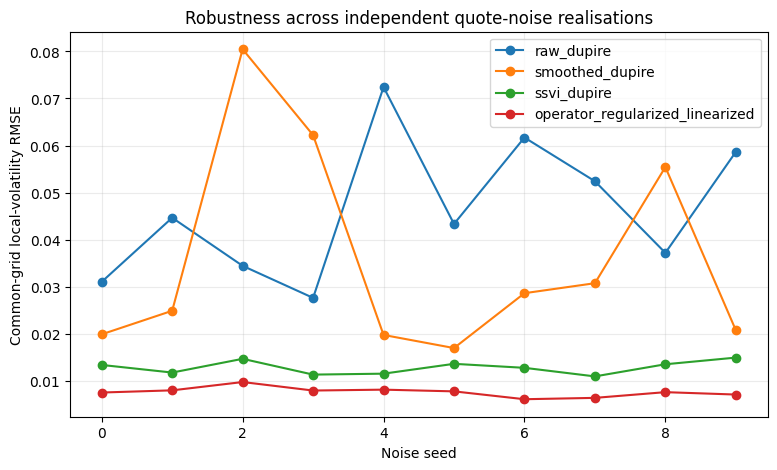

In [10]:
plt.figure(figsize=(9, 5))
for method in noise_results["method"].unique():
    method_data = noise_results[noise_results["method"] == method]
    plt.plot(
        method_data["seed"],
        method_data["rmse"],
        marker="o",
        label=method,
    )
plt.xlabel("Noise seed")
plt.ylabel("Common-grid local-volatility RMSE")
plt.title("Robustness across independent quote-noise realisations")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

## 7. Final interpretation

Read this experiment together with the earlier smooth-smile and isolated-bump
experiments:

- raw Dupire exposes the instability of direct numerical differentiation;
- generic price smoothing improves stability but can distort local structure;
- SSVI is strong when global smooth structure dominates;
- the operator method is designed to retain smoothness while allowing broader
  non-parametric departures that SSVI may compress.

This final experiment is synthetic, so it does not replace multi-date market
validation. Its role is to test the models on a more realistic known truth than
a single isolated bump.

In [11]:
print("Single-noise winner:", summary["single_noise_local_volatility_winner"])
print("Repeated-noise winner:", summary["repeated_noise_mean_rmse_winner"])
print("Selected lambda:", summary["selected_lambda"])
print("Shared valid fraction:", summary["shared_valid_fraction"])

Single-noise winner: operator_regularized
Repeated-noise winner: operator_regularized_linearized
Selected lambda: 1000.0
Shared valid fraction: 0.8823529411764706
